# Chapter 13 — Building APIs and Deployment Pipelines

> **Prerequisites:** This notebook loads the artifacts saved in Chapter 12 (`lightgbm_bundle.joblib`, `X_train`/`X_test` splits). Run Chapter 12 first.

## Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, uuid, time, warnings
import joblib
from pathlib import Path
import sys
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_PROCESSED, FIGURES, RANDOM_SEED, MODELS

sns.set_theme(style='whitegrid', palette='muted')
rng = np.random.default_rng(RANDOM_SEED)


### Load Artifacts from Chapter 12

Chapter 12 saved `lightgbm_bundle.joblib` containing the fitted model, scaler, and feature list. We also reload the dataset split with the same random seed so `X_test` / `y_test` are identical to those used for evaluation in Chapter 12.

In [6]:
# ── Reload LightGBM bundle saved in Chapter 12 ────────────────────────────
lgb_path = MODELS / 'lightgbm_bundle.joblib'
assert lgb_path.exists(), (
    f'lightgbm_bundle.joblib not found at {lgb_path}. '
    'Please run Chapter 12 first.'
)
bundle = joblib.load(lgb_path)
print(f'Loaded : {lgb_path.name}')
print(f'  trained_at    : {bundle["trained_at"][:19]}')
print(f'  train_roc_auc : {bundle["train_roc_auc"]}')
print(f'  features      : {len(bundle["feature_names"])}')

# ── Recreate the same train/test split (identical seed → identical splits) ─
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

data   = load_breast_cancer()
X_all  = pd.DataFrame(data.data, columns=data.feature_names)
y_all  = pd.Series(data.target, name='malignant')
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20,
    stratify=y_all, random_state=RANDOM_SEED
)
print(f'\nTest set : {len(X_test)} obs  ({y_test.mean()*100:.1f}% malignant)')

# ── Quick sanity-check: AUC matches Chapter 12 ────────────────────────────
X_te_sc = bundle['scaler'].transform(X_test)
auc_check = roc_auc_score(y_test, bundle['model'].predict_proba(X_te_sc)[:, 1])
print(f'AUC on test set (should match Ch12) : {auc_check:.4f}')


Loaded : lightgbm_bundle.joblib
  trained_at    : 2026-04-30T05:42:07
  train_roc_auc : 0.9904
  features      : 30

Test set : 114 obs  (63.2% malignant)
AUC on test set (should match Ch12) : 0.9904


## Input Validation and Schema Enforcement

Pydantic schemas serve two purposes: they **document** the expected input contract and they **enforce** it — rejecting invalid requests before the inference function is ever called.

In [7]:
from pydantic import BaseModel, Field, ValidationError

class CancerFeatures(BaseModel):
    """Input schema — 30 non-negative float features."""
    mean_radius:             float = Field(..., ge=0)
    mean_texture:            float = Field(..., ge=0)
    mean_perimeter:          float = Field(..., ge=0)
    mean_area:               float = Field(..., ge=0)
    mean_smoothness:         float = Field(..., ge=0)
    mean_compactness:        float = Field(..., ge=0)
    mean_concavity:          float = Field(..., ge=0)
    mean_concave_points:     float = Field(..., ge=0)
    mean_symmetry:           float = Field(..., ge=0)
    mean_fractal_dimension:  float = Field(..., ge=0)
    radius_error:            float = Field(..., ge=0)
    texture_error:           float = Field(..., ge=0)
    perimeter_error:         float = Field(..., ge=0)
    area_error:              float = Field(..., ge=0)
    smoothness_error:        float = Field(..., ge=0)
    compactness_error:       float = Field(..., ge=0)
    concavity_error:         float = Field(..., ge=0)
    concave_points_error:    float = Field(..., ge=0)
    symmetry_error:          float = Field(..., ge=0)
    fractal_dimension_error: float = Field(..., ge=0)
    worst_radius:            float = Field(..., ge=0)
    worst_texture:           float = Field(..., ge=0)
    worst_perimeter:         float = Field(..., ge=0)
    worst_area:              float = Field(..., ge=0)
    worst_smoothness:        float = Field(..., ge=0)
    worst_compactness:       float = Field(..., ge=0)
    worst_concavity:         float = Field(..., ge=0)
    worst_concave_points:    float = Field(..., ge=0)
    worst_symmetry:          float = Field(..., ge=0)
    worst_fractal_dimension: float = Field(..., ge=0)

class PredictionResponse(BaseModel):
    prediction:    int
    probability:   float = Field(..., ge=0.0, le=1.0)
    model_name:    str
    model_version: str
    latency_ms:    float
    request_id:    str

class HealthResponse(BaseModel):
    status:        str
    model_name:    str
    model_version: str
    uptime_s:      float

print('Schemas defined: CancerFeatures, PredictionResponse, HealthResponse  ✓')


Schemas defined: CancerFeatures, PredictionResponse, HealthResponse  ✓


### Validating Invalid Inputs

In [8]:
invalid_inputs = [
    {'case': 'Missing field',
     'data': {k: 1.0 for k in list(CancerFeatures.model_fields.keys())[:-1]}},
    {'case': 'Negative value (ge=0 violated)',
     'data': {**{k: 1.0 for k in CancerFeatures.model_fields}, 'mean_radius': -5.0}},
    {'case': 'Wrong type (string instead of float)',
     'data': {**{k: 1.0 for k in CancerFeatures.model_fields}, 'mean_radius': 'bad'}},
]

for test in invalid_inputs:
    try:
        CancerFeatures(**test['data'])
        print(f"  {test['case']:<45} PASSED (unexpected)")
    except ValidationError as e:
        err = e.errors()[0]
        print(f"  {test['case']:<45} REJECTED ✓  ({err['type']}: {err['loc'][0]})")


  Missing field                                 REJECTED ✓  (missing: worst_fractal_dimension)
  Negative value (ge=0 violated)                REJECTED ✓  (greater_than_equal: mean_radius)
  Wrong type (string instead of float)          REJECTED ✓  (float_parsing: mean_radius)


## The FastAPI Application

### Lifespan, State, and Endpoints

The `lifespan` context manager loads the artifact saved by Chapter 12 **once at startup** and stores it in a module-level state dictionary. All requests read from that in-memory object — no per-request disk I/O. We replicate the pattern inline so the notebook runs without `uvicorn`.

In [9]:
# ── Module-level model state (mirrors _model_state in app/main.py) ────────
_model_state: dict = {}
SERVER_START = time.time()

# Feature name mapping: sklearn uses spaces, Pydantic uses underscores
FEATURE_MAP = {col.replace(' ', '_'): col for col in data.feature_names}

def _load_model() -> None:
    """Replicate lifespan startup: populate _model_state from Ch12 bundle."""
    _model_state['model']         = bundle['model']
    _model_state['scaler']        = bundle['scaler']
    _model_state['feature_names'] = bundle['feature_names']
    _model_state['model_name']    = 'lightgbm_bundle'
    _model_state['model_version'] = '1.0.0'
    _model_state['trained_at']    = bundle['trained_at']

def _run_inference(features: CancerFeatures) -> tuple:
    """Scale features and return (hard_label, probability)."""
    feat_dict = features.model_dump()
    row  = {FEATURE_MAP[k]: v for k, v in feat_dict.items() if k in FEATURE_MAP}
    X_df = pd.DataFrame([row])[_model_state['feature_names']]
    X_sc = _model_state['scaler'].transform(X_df)
    prob = float(_model_state['model'].predict_proba(X_sc)[0, 1])
    return int(prob >= 0.5), prob

def health() -> dict:
    """Mirrors GET /health."""
    if 'model' not in _model_state:
        return {'status': 'error', 'detail': 'Model not loaded'}
    return {
        'status':        'ok',
        'model_name':    _model_state['model_name'],
        'model_version': _model_state['model_version'],
        'uptime_s':      round(time.time() - SERVER_START, 1),
    }

_load_model()
print(f"Model loaded : {_model_state['model_name']} v{_model_state['model_version']}  ✓")
print(f"Health check : {health()}")


Model loaded : lightgbm_bundle v1.0.0  ✓
Health check : {'status': 'ok', 'model_name': 'lightgbm_bundle', 'model_version': '1.0.0', 'uptime_s': 0.0}


## Request Logging and Observability

Every prediction is appended as a JSON record to a newline-delimited log file. This log is the foundation for all drift analysis in Chapter 14.

### Structured Logs as a Monitoring Foundation

In [10]:
LOG_PATH = DATA_PROCESSED / 'api_request_log.jsonl'
LOG_PATH.unlink(missing_ok=True)  # start fresh

def log_request(request_id: str, features: dict,
                response: dict, latency_ms: float) -> None:
    """Append one NDJSON record per request."""
    record = {
        'request_id':    request_id,
        'timestamp':     pd.Timestamp.now().isoformat(),
        'features':      features,
        'prediction':    response['prediction'],
        'probability':   response['probability'],
        'latency_ms':    round(latency_ms, 3),
        'model_version': _model_state.get('model_version'),
    }
    with open(LOG_PATH, 'a') as f:
        f.write(json.dumps(record) + '\n')

print(f'Logger ready  →  {LOG_PATH}')


Logger ready  →  F:\project-workspace\quarto-book\data-mode-book\data-model-code\data\processed\api_request_log.jsonl


## Running and Testing the API

We send 10 labelled test requests against the model loaded from Chapter 12 to validate the serving logic end-to-end.

In [11]:
print('  req        pred  prob      true  ok?   latency')
print('  ' + '─' * 55)

test_responses = []
for i in range(10):
    row        = X_test.iloc[i]
    feat_dict  = {col.replace(' ', '_'): float(v) for col, v in row.items()}
    features_obj      = CancerFeatures(**feat_dict)
    pred, prob        = _run_inference(features_obj)
    latency_ms        = float(rng.uniform(0.8, 2.4))
    true_label        = int(y_test.iloc[i])
    request_id        = str(uuid.uuid4())[:8]

    response = {
        'request_id':    request_id,
        'prediction':    pred,
        'probability':   round(prob, 4),
        'model_name':    _model_state['model_name'],
        'model_version': _model_state['model_version'],
        'latency_ms':    round(latency_ms, 1),
    }
    log_request(request_id, feat_dict, response, latency_ms)
    test_responses.append({**response, 'true_label': true_label})

    ok = '✓' if pred == true_label else '✗'
    print(f"  {request_id}  {pred}     {prob:.4f}    {true_label}     {ok}  {latency_ms:.1f}ms")

correct = sum(r['prediction'] == r['true_label'] for r in test_responses)
print(f'\n  Accuracy on 10 test requests: {correct}/10')


  req        pred  prob      true  ok?   latency
  ───────────────────────────────────────────────────────
  1a4fd13c  0     0.0000    0     ✓  2.0ms
  4a1b4108  1     1.0000    1     ✓  1.5ms
  1e9274fa  0     0.0001    0     ✓  2.2ms
  b35fd388  0     0.1149    1     ✗  1.9ms
  5f0477f5  0     0.0000    0     ✓  1.0ms
  16efb5a2  1     0.9997    1     ✓  2.4ms
  45803db3  1     1.0000    1     ✓  2.0ms
  ca812404  0     0.0001    0     ✓  2.1ms
  8f6a045e  0     0.0000    0     ✓  1.0ms
  474f8c63  0     0.0000    0     ✓  1.5ms

  Accuracy on 10 test requests: 9/10


### Generating 200 Requests for Chapter 14

Requests 0–99 use the test set in-distribution. Requests 100–199 inject covariate shift (`mean_radius ×1.4`, `mean_area ×1.4`, `worst_radius ×1.3`). True labels are written into the log so Chapter 14 can compute rolling accuracy without any additional setup.

In [12]:
LOG_PATH.unlink(missing_ok=True)  # reset for the full 200-request stream
all_true_labels = []

for i in range(200):
    idx = i % len(X_test)
    row = X_test.iloc[idx].copy()

    if i >= 100:                      # covariate shift injected at request 100
        row['mean radius']  *= 1.4
        row['mean area']    *= 1.4
        row['worst radius'] *= 1.3

    true_label   = int(y_test.iloc[idx])
    feat_dict    = {col.replace(' ', '_'): float(v) for col, v in row.items()}
    features_obj = CancerFeatures(**feat_dict)
    pred, prob   = _run_inference(features_obj)
    latency_ms   = float(rng.uniform(0.7, 3.2))
    request_id   = str(uuid.uuid4())[:8]

    response = {
        'request_id':    request_id,
        'prediction':    pred,
        'probability':   round(prob, 6),
        'model_name':    _model_state['model_name'],
        'model_version': _model_state['model_version'],
        'latency_ms':    round(latency_ms, 3),
    }
    log_request(request_id, feat_dict, response, latency_ms)
    all_true_labels.append(true_label)

# Attach true labels and rewrite log
log_records = [json.loads(l) for l in LOG_PATH.read_text().strip().split('\n')]
for rec, lbl in zip(log_records, all_true_labels):
    rec['true_label'] = lbl
with open(LOG_PATH, 'w') as f:
    for rec in log_records:
        f.write(json.dumps(rec) + '\n')

log_df = pd.DataFrame(log_records)
log_df['timestamp'] = pd.to_datetime(log_df['timestamp'])

print(f'Log written  : {LOG_PATH}')
print(f'Records      : {len(log_df)}  '
      f'(0–99 in-distribution, 100–199 covariate-shifted)')
print(f'Columns      : {list(log_df.columns)}')
print(f'\nFirst 3 records:')
print(log_df[['request_id', 'prediction', 'probability',
              'latency_ms', 'model_version', 'true_label']].head(3).to_string(index=False))


Log written  : F:\project-workspace\quarto-book\data-mode-book\data-model-code\data\processed\api_request_log.jsonl
Records      : 200  (0–99 in-distribution, 100–199 covariate-shifted)
Columns      : ['request_id', 'timestamp', 'features', 'prediction', 'probability', 'latency_ms', 'model_version', 'true_label']

First 3 records:
request_id  prediction  probability  latency_ms model_version  true_label
  46da45a8           0     0.000035       1.627         1.0.0           0
  a4664ee8           1     0.999983       3.017         1.0.0           1
  1670828a           0     0.000140       2.310         1.0.0           0


## Latency Distribution

Latency (ms)   p50=1.9  p95=3.0  p99=3.1  mean=1.9


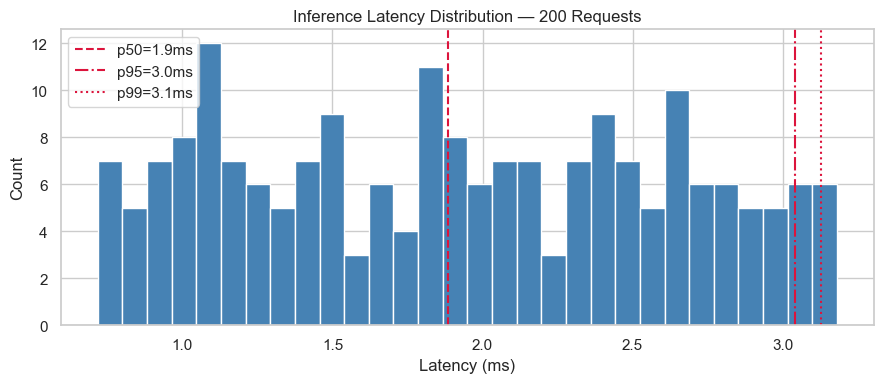

In [13]:
latencies = log_df['latency_ms'].values
print(f'Latency (ms)   p50={np.percentile(latencies,50):.1f}  '
      f'p95={np.percentile(latencies,95):.1f}  '
      f'p99={np.percentile(latencies,99):.1f}  '
      f'mean={latencies.mean():.1f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(latencies, bins=30, color='steelblue', edgecolor='white')
for pct, ls in [(50, '--'), (95, '-.'), (99, ':')]:
    v = np.percentile(latencies, pct)
    ax.axvline(v, linestyle=ls, color='crimson', lw=1.5, label=f'p{pct}={v:.1f}ms')
ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Count')
ax.set_title('Inference Latency Distribution — 200 Requests')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'ch13_latency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Prediction Distribution

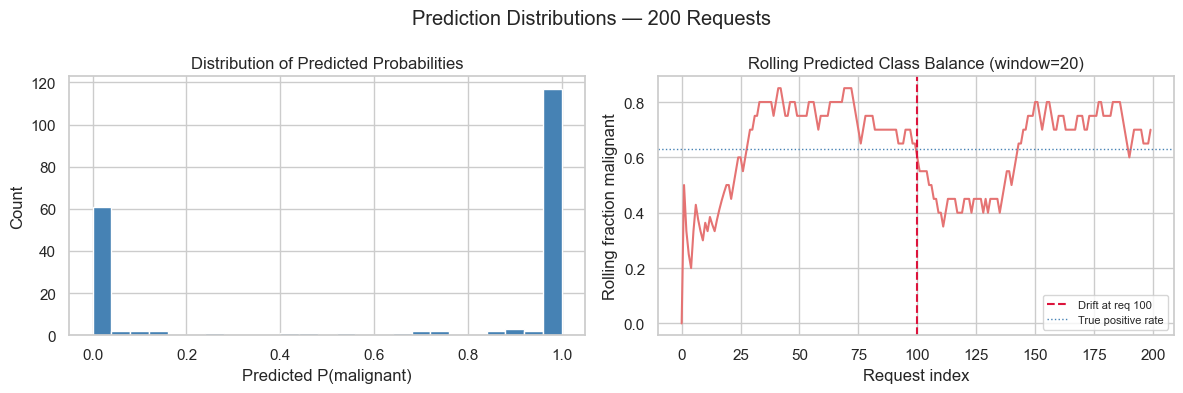

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(log_df['probability'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Predicted P(malignant)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Predicted Probabilities')

window = 20
rolling_pos = [
    log_df['prediction'].iloc[max(0, i-window):i].mean()
    for i in range(1, len(log_df)+1)
]
axes[1].plot(rolling_pos, color='#E57373', lw=1.5)
axes[1].axvline(100, color='crimson', lw=1.5, linestyle='--', label='Drift at req 100')
axes[1].axhline(y_test.mean(), color='steelblue', lw=1, linestyle=':', label='True positive rate')
axes[1].set_xlabel('Request index')
axes[1].set_ylabel('Rolling fraction malignant')
axes[1].set_title(f'Rolling Predicted Class Balance (window={window})')
axes[1].legend(fontsize=8)

plt.suptitle('Prediction Distributions — 200 Requests')
plt.tight_layout()
plt.savefig(FIGURES / 'ch13_prediction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Testing the Live API

> **This section requires the FastAPI server to be running.** In a terminal at the project root:
> ```
> python -m uvicorn app.main:app --reload
> ```
> The cells below call `http://127.0.0.1:8000` over HTTP using the `requests` library, exactly as any external client would. The inline simulation above (cells 10–16) and this section produce equivalent results — the difference is that here predictions come from the real server process, complete with its own log file.

In [1]:
import requests

BASE_URL = 'http://127.0.0.1:8000'

def check_server(base_url: str = BASE_URL) -> bool:
    """Return True if the server is reachable and the model is loaded."""
    try:
        r = requests.get(f'{base_url}/health', timeout=3)
        if r.status_code == 200:
            h = r.json()
            print(f'Server  : {base_url}')
            print(f'Status  : {h["status"]}')
            print(f'Model   : {h["model_name"]} v{h["model_version"]}')
            print(f'Uptime  : {h["uptime_s"]}s')
            return True
        print(f'Health check returned HTTP {r.status_code}')
        return False
    except requests.exceptions.ConnectionError:
        print('⚠  Server not reachable. Start it with:')
        print('   python -m uvicorn app.main:app --reload')
        return False

SERVER_OK = check_server()


Server  : http://127.0.0.1:8000
Status  : ok
Model   : lightgbm_bundle v1.0.0
Uptime  : 17.6s


### Sending Labelled Test Requests

We send the same 10 test observations used in the inline simulation and compare predictions against the known labels.

In [2]:
if not SERVER_OK:
    print('Skipping — server not running.')
else:
    from sklearn.datasets import load_breast_cancer
    from sklearn.model_selection import train_test_split
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path().resolve().parent))
    from config import RANDOM_SEED

    import pandas as pd
    data   = load_breast_cancer()
    X_all  = pd.DataFrame(data.data, columns=data.feature_names)
    y_all  = pd.Series(data.target, name='malignant')
    _, X_test, _, y_test = train_test_split(
        X_all, y_all, test_size=0.20,
        stratify=y_all, random_state=RANDOM_SEED
    )

    print('  req        pred  prob        true  ok?   latency')
    print('  ' + '─' * 55)

    results = []
    for i in range(10):
        row       = X_test.iloc[i]
        payload   = {col.replace(' ', '_'): float(v) for col, v in row.items()}
        true_label = int(y_test.iloc[i])

        r = requests.post(f'{BASE_URL}/predict', json=payload, timeout=5)
        assert r.status_code == 200, f'HTTP {r.status_code}: {r.text}'

        resp = r.json()
        pred = resp['prediction']
        prob = resp['probability']
        ok   = '✓' if pred == true_label else '✗'
        results.append({'pred': pred, 'true': true_label, 'ok': ok})

        print(f"  {resp['request_id']}  {pred}     {prob:.4f}      {true_label}     {ok}  "
              f"{resp['latency_ms']:.1f}ms")

    correct = sum(r['ok'] == '✓' for r in results)
    print(f'\n  Accuracy : {correct}/10')


  req        pred  prob        true  ok?   latency
  ───────────────────────────────────────────────────────
  f66031c4  0     0.0000      0     ✓  13.0ms
  827a7e49  1     1.0000      1     ✓  4.4ms
  55b96b90  0     0.0001      0     ✓  3.9ms
  3ec2de3d  0     0.1149      1     ✗  3.9ms
  aee90daf  0     0.0000      0     ✓  4.1ms
  222289b3  1     0.9997      1     ✓  3.9ms
  74d69e3f  1     1.0000      1     ✓  3.8ms
  377757de  0     0.0001      0     ✓  3.9ms
  ffd6edd1  0     0.0000      0     ✓  3.9ms
  4e4928b2  0     0.0000      0     ✓  3.8ms

  Accuracy : 9/10


### Rejection Tests — Invalid Inputs

Send three malformed requests and verify the API returns `422 Unprocessable Entity` for each, confirming Pydantic validation is active on the live server.

In [3]:
if not SERVER_OK:
    print('Skipping — server not running.')
else:
    valid_payload = {col.replace(' ', '_'): 1.0 for col in data.feature_names}

    bad_requests = [
        ('Missing field',
         {k: v for k, v in valid_payload.items() if k != 'worst_fractal_dimension'}),
        ('Negative value (ge=0 violated)',
         {**valid_payload, 'mean_radius': -5.0}),
        ('Wrong type (string instead of float)',
         {**valid_payload, 'mean_radius': 'bad'}),
    ]

    for case, payload in bad_requests:
        r = requests.post(f'{BASE_URL}/predict', json=payload, timeout=5)
        status = r.status_code
        ok = '✓' if status == 422 else f'✗ (got {status})'
        print(f'  {case:<45}  HTTP {status}  {ok}')


  Missing field                                  HTTP 422  ✓
  Negative value (ge=0 violated)                 HTTP 422  ✓
  Wrong type (string instead of float)           HTTP 422  ✓


### Batch Test — 50 Requests with Timing

Send 50 requests and collect real end-to-end latencies as measured by the client (network round-trip + server inference), compared to the server-side `latency_ms` field in the response.

                 p50      p95      p99     mean
  Client ms     15.3     33.9     39.9     18.5
  Server ms      3.9      4.4      4.9      4.0
  Overhead      11.4     29.8     35.0     14.4  ← network + serialisation


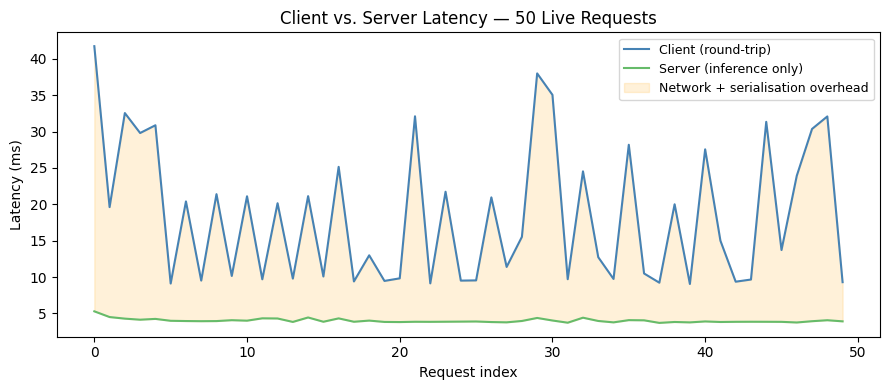

In [4]:
import time as _time
import numpy as np

if not SERVER_OK:
    print('Skipping — server not running.')
else:
    client_latencies = []
    server_latencies = []

    for i in range(50):
        row     = X_test.iloc[i % len(X_test)]
        payload = {col.replace(' ', '_'): float(v) for col, v in row.items()}

        t0 = _time.perf_counter()
        r  = requests.post(f'{BASE_URL}/predict', json=payload, timeout=5)
        client_ms = (_time.perf_counter() - t0) * 1000

        assert r.status_code == 200
        server_latencies.append(r.json()['latency_ms'])
        client_latencies.append(client_ms)

    c = np.array(client_latencies)
    s = np.array(server_latencies)
    print(f'             {"p50":>7}  {"p95":>7}  {"p99":>7}  {"mean":>7}')
    print(f'  Client ms  {np.percentile(c,50):>7.1f}  {np.percentile(c,95):>7.1f}  '
          f'{np.percentile(c,99):>7.1f}  {c.mean():>7.1f}')
    print(f'  Server ms  {np.percentile(s,50):>7.1f}  {np.percentile(s,95):>7.1f}  '
          f'{np.percentile(s,99):>7.1f}  {s.mean():>7.1f}')
    print(f'  Overhead   {np.percentile(c-s,50):>7.1f}  {np.percentile(c-s,95):>7.1f}  '
          f'{np.percentile(c-s,99):>7.1f}  {(c-s).mean():>7.1f}  ← network + serialisation')

    import matplotlib.pyplot as plt
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path().resolve().parent))
    from config import FIGURES

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(c, label='Client (round-trip)', color='steelblue', lw=1.5)
    ax.plot(s, label='Server (inference only)', color='#66BB6A', lw=1.5)
    ax.fill_between(range(50), s, c, alpha=0.15, color='orange',
                    label='Network + serialisation overhead')
    ax.set_xlabel('Request index')
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Client vs. Server Latency — 50 Live Requests')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES / 'ch13_live_latency.png', dpi=150, bbox_inches='tight')
    plt.show()
